<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/41_Backtest_Performance_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TSLA 백테스트 성과평가 실습
**Notebook:** `TSLA_Backtest_Performance_Metrics.ipynb`  
**실행 환경:** Google Colab 권장

## 실습 목표
이 실습에서는 **테슬라(TSLA) 주가 데이터**를 이용하여 간단한 예측 기반 전략을 만들고,  
그 전략의 백테스트 성과를 다음 지표로 계산하고 해석합니다.

- 샤프 지수 (Sharpe Ratio)
- 소르티노 지수 (Sortino Ratio)
- 누적 수익률 (Cumulative Return)
- 연간 수익률 (Annual Return / CAGR)
- 연간 변동성 (Annual Volatility)
- 최대 손실폭 (Maximum Drawdown, MDD)

## 실습 흐름
1. TSLA 데이터 다운로드  
2. 수익률 계산  
3. lag feature 생성  
4. 간단한 선형회귀 예측  
5. 예측 기반 포지션 생성  
6. 전략 수익률 계산  
7. 성과지표 계산  
8. Buy & Hold와 비교  
9. 누적수익률 / Drawdown 시각화  

## 주의사항
이 노트북은 **교육용 예제**입니다.  
거래비용, 세금, 슬리피지, 체결 문제는 단순화했습니다.


In [1]:
# 1. 라이브러리 설치 및 불러오기

try:
    import yfinance as yf
except ImportError:
    !pip -q install yfinance
    import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. TSLA 데이터 다운로드
Yahoo Finance에서 2018년 이후 TSLA 일별 데이터를 가져옵니다.


In [2]:
# 2. TSLA 데이터 다운로드

ticker = "TSLA"
start_date = "2018-01-01"
end_date = "2025-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)

print("Downloaded data shape:", df.shape)
display(df.head())


Downloaded data shape: (1761, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2018-01-02,21.368668,21.368668,21.474001,20.733334,20.799999,65283000
2018-01-03,21.150000,21.150000,21.683332,21.036667,21.400000,67822500
2018-01-04,20.974667,20.974667,21.236668,20.378668,20.858000,149194500
2018-01-05,21.105333,21.105333,21.149332,20.799999,21.108000,68868000
2018-01-08,22.427334,22.427334,22.468000,21.033333,21.066668,147891000


## 2. MultiIndex 컬럼 안전 처리
`yfinance` 결과는 환경에 따라 MultiIndex 컬럼일 수 있으므로 안전하게 종가를 추출합니다.


In [3]:
# 3. MultiIndex-safe 종가 추출

def get_close_series(dataframe, ticker_symbol):
    if isinstance(dataframe.columns, pd.MultiIndex):
        return dataframe[("Close", ticker_symbol)].copy()
    return dataframe["Close"].copy()

close_price = get_close_series(df, ticker)
close_price.name = "Close"

display(close_price.head())


,Close
Date,
2018-01-02,21.368668
2018-01-03,21.150000
2018-01-04,20.974667
2018-01-05,21.105333
2018-01-08,22.427334


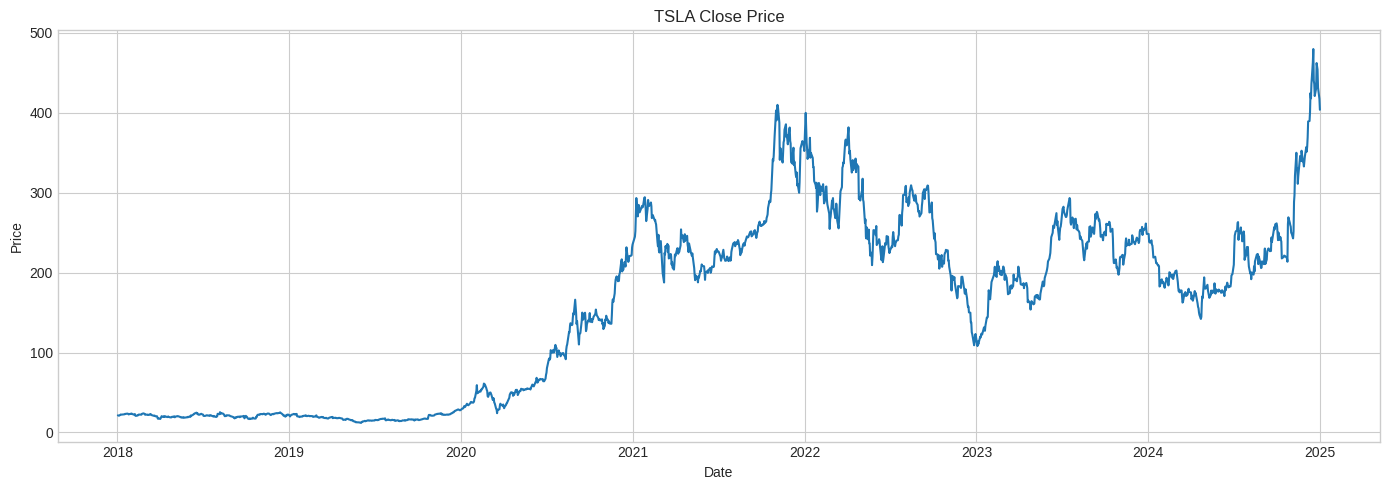

In [4]:
# 4. TSLA 종가 시각화

plt.figure(figsize=(14, 5))
plt.plot(close_price.index, close_price, linewidth=1.5)
plt.title("TSLA Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 3. 일별 수익률 계산
성과평가 지표는 보통 **가격이 아니라 수익률** 기준으로 계산합니다.

단순수익률:
\[
r_t = \frac{P_t}{P_{t-1}} - 1
\]


In [5]:
# 5. 일별 단순수익률 계산

data = pd.DataFrame(index=close_price.index)
data["Close"] = close_price
data["Return"] = data["Close"].pct_change()

display(data.head(10))


,Close,Return
Date,,
2018-01-02,21.368668,NaN
2018-01-03,21.150000,-0.010233
2018-01-04,20.974667,-0.008290
2018-01-05,21.105333,0.006230
2018-01-08,22.427334,0.062638
2018-01-09,22.246000,-0.008085
2018-01-10,22.320000,0.003326
2018-01-11,22.530001,0.009409
2018-01-12,22.414667,-0.005119


## 4. 예측용 lag feature 생성
이번 예제에서는 최근 5일 수익률을 입력으로 사용하여 **내일 수익률**을 예측합니다.


In [6]:
# 6. lag feature 생성

n_lags = 5

for lag in range(1, n_lags + 1):
    data[f"lag_{lag}"] = data["Return"].shift(lag)

data["Target_Next_Return"] = data["Return"].shift(-1)
data = data.dropna().copy()

display(data.head())
print("Prepared dataset shape:", data.shape)


,Close,Return,lag_1,lag_2,lag_3,lag_4,lag_5,Target_Next_Return
Date,,,,,,,,
2018-01-10,22.320000,0.003326,-0.008085,0.062638,0.006230,-0.008290,-0.010233,0.009409
2018-01-11,22.530001,0.009409,0.003326,-0.008085,0.062638,0.006230,-0.008290,-0.005119
2018-01-12,22.414667,-0.005119,0.009409,0.003326,-0.008085,0.062638,0.006230,0.011421
2018-01-16,22.670668,0.011421,-0.005119,0.009409,0.003326,-0.008085,0.062638,0.020879
2018-01-17,23.143999,0.020879,0.011421,-0.005119,0.009409,0.003326,-0.008085,-0.007461


Prepared dataset shape: (1754, 8)


## 5. 시계열 순서를 유지한 train / test split
시계열은 무작위로 섞지 않고 **과거로 학습하고 미래로 평가**해야 합니다.


In [7]:
# 7. Train / Test split

feature_cols = [f"lag_{i}" for i in range(1, n_lags + 1)]
target_col = "Target_Next_Return"

split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train size:", len(train))
print("Test size :", len(test))


Train size: 1403
Test size : 351


## 6. 간단한 예측 모델 학습
복잡한 딥러닝 대신 **Linear Regression**을 사용합니다.  
이번 실습의 핵심은 모델 경쟁이 아니라 **성과지표 계산과 해석**입니다.


In [8]:
# 8. 선형회귀 예측 모델 학습

model = LinearRegression()
model.fit(X_train, y_train)

test["Predicted_Next_Return"] = model.predict(X_test)

display(test[["Return", "Target_Next_Return", "Predicted_Next_Return"]].head())


,Return,Target_Next_Return,Predicted_Next_Return
Date,,,
2023-08-09,-0.030076,0.013006,0.001067
2023-08-10,0.013006,-0.010964,0.001588
2023-08-11,-0.010964,-0.011910,0.002030
2023-08-14,-0.011910,-0.028362,0.002598
2023-08-15,-0.028362,-0.031593,0.002880


In [9]:
# 9. 예측 오차 계산

pred_mae = mean_absolute_error(test["Target_Next_Return"], test["Predicted_Next_Return"])
pred_rmse = np.sqrt(mean_squared_error(test["Target_Next_Return"], test["Predicted_Next_Return"]))

print("Prediction MAE :", pred_mae)
print("Prediction RMSE:", pred_rmse)


Prediction MAE : 0.026953099179935727
Prediction RMSE: 0.03741882980778073


## 7. 예측 결과를 매매 신호로 변환
단순 전략 규칙:
- 예측 수익률 > 0 이면 **매수(1)**
- 예측 수익률 ≤ 0 이면 **현금 보유(0)**

즉, “내일 오를 것 같으면 보유하고 아니면 쉰다”는 전략입니다.


In [10]:
# 10. 포지션 생성

test["Position"] = np.where(test["Predicted_Next_Return"] > 0, 1.0, 0.0)
display(test[["Predicted_Next_Return", "Position"]].head(10))


,Predicted_Next_Return,Position
Date,,
2023-08-09,0.001067,1.0
2023-08-10,0.001588,1.0
2023-08-11,0.002030,1.0
2023-08-14,0.002598,1.0
2023-08-15,0.002880,1.0
2023-08-16,0.000698,1.0
2023-08-17,0.000311,1.0
2023-08-18,0.000350,1.0
2023-08-21,0.001415,1.0


## 8. 전략 수익률 계산
오늘의 포지션으로 **다음 날 실제 수익률**을 받는다고 가정하므로 포지션을 한 칸 이동시킵니다.


In [11]:
# 11. 전략 수익률 계산

test["Strategy_Return"] = test["Position"].shift(1) * test["Return"]
test["BuyHold_Return"] = test["Return"]

test = test.dropna().copy()

display(test[["Return", "Position", "Strategy_Return", "BuyHold_Return"]].head())


,Return,Position,Strategy_Return,BuyHold_Return
Date,,,,
2023-08-10,0.013006,1.0,0.013006,0.013006
2023-08-11,-0.010964,1.0,-0.010964,-0.010964
2023-08-14,-0.011910,1.0,-0.011910,-0.011910
2023-08-15,-0.028362,1.0,-0.028362,-0.028362
2023-08-16,-0.031593,1.0,-0.031593,-0.031593


In [12]:
# 12. 누적수익률 계산

test["Strategy_Equity"] = (1 + test["Strategy_Return"]).cumprod()
test["BuyHold_Equity"] = (1 + test["BuyHold_Return"]).cumprod()

display(test[["Strategy_Equity", "BuyHold_Equity"]].head())


,Strategy_Equity,BuyHold_Equity
Date,,
2023-08-10,1.013006,1.013006
2023-08-11,1.001899,1.001899
2023-08-14,0.989967,0.989967
2023-08-15,0.961889,0.961889
2023-08-16,0.931500,0.931500


## 9. 금융 성과지표 함수 만들기
이제 다음 지표를 계산합니다.

- Sharpe Ratio
- Sortino Ratio
- Cumulative Return
- Annual Return (CAGR)
- Annual Volatility
- Maximum Drawdown (MDD)

주식 일별 데이터이므로 연율화 기준은 **252 거래일**로 둡니다.


In [13]:
# 13. 성과지표 계산 함수

TRADING_DAYS = 252

def sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    excess_returns = returns - risk_free_rate / periods_per_year
    ann_excess_return = excess_returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    if ann_vol == 0:
        return np.nan
    return ann_excess_return / ann_vol

def sortino_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    excess_returns = returns - risk_free_rate / periods_per_year
    downside = excess_returns[excess_returns < 0]
    downside_std = downside.std() * np.sqrt(periods_per_year)
    ann_excess_return = excess_returns.mean() * periods_per_year
    if downside_std == 0 or np.isnan(downside_std):
        return np.nan
    return ann_excess_return / downside_std

def cumulative_return(returns):
    returns = pd.Series(returns).dropna()
    return (1 + returns).prod() - 1

def annual_return_cagr(returns, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    total_periods = len(returns)
    total_return = (1 + returns).prod()
    years = total_periods / periods_per_year
    if years == 0:
        return np.nan
    return total_return ** (1 / years) - 1

def annual_volatility(returns, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    return returns.std() * np.sqrt(periods_per_year)

def max_drawdown(returns):
    returns = pd.Series(returns).dropna()
    equity_curve = (1 + returns).cumprod()
    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1
    return drawdown.min()

def performance_summary(returns, name="Strategy"):
    returns = pd.Series(returns).dropna()
    summary = {
        "Strategy": name,
        "Sharpe Ratio": sharpe_ratio(returns),
        "Sortino Ratio": sortino_ratio(returns),
        "Cumulative Return": cumulative_return(returns),
        "Annual Return": annual_return_cagr(returns),
        "Annual Volatility": annual_volatility(returns),
        "Max Drawdown": max_drawdown(returns)
    }
    return pd.DataFrame([summary])


## 10. Buy & Hold vs 예측 전략 비교
이제 두 전략의 성과를 같은 표에서 비교합니다.

- **Buy & Hold**: TSLA를 그냥 계속 보유
- **ML Prediction Strategy**: 예측이 양수일 때만 보유


In [14]:
# 14. 성과지표 계산

summary_buyhold = performance_summary(test["BuyHold_Return"], name="Buy & Hold")
summary_strategy = performance_summary(test["Strategy_Return"], name="ML Prediction Strategy")

summary_table = pd.concat([summary_buyhold, summary_strategy], ignore_index=True)
display(summary_table)


,Strategy,Sharpe Ratio,Sortino Ratio,Cumulative Return,Annual Return,Annual Volatility,Max Drawdown
0,Buy & Hold,0.950541,1.652645,0.723482,0.479833,0.594598,-0.485401
1,ML Prediction Strategy,0.723370,1.173569,0.422407,0.288775,0.571525,-0.505205


In [15]:
# 15. 보기 좋은 형식으로 결과 정리

formatted = summary_table.copy()

percent_cols = ["Cumulative Return", "Annual Return", "Annual Volatility", "Max Drawdown"]

for col in percent_cols:
    formatted[col] = formatted[col].apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "NaN")

for col in ["Sharpe Ratio", "Sortino Ratio"]:
    formatted[col] = formatted[col].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "NaN")

display(formatted)


,Strategy,Sharpe Ratio,Sortino Ratio,Cumulative Return,Annual Return,Annual Volatility,Max Drawdown
0,Buy & Hold,0.9505,1.6526,72.35%,47.98%,59.46%,-48.54%
1,ML Prediction Strategy,0.7234,1.1736,42.24%,28.88%,57.15%,-50.52%


## 11. 누적 수익률 곡선 시각화
이 그래프는 두 전략의 **성장 경로**를 직관적으로 보여줍니다.


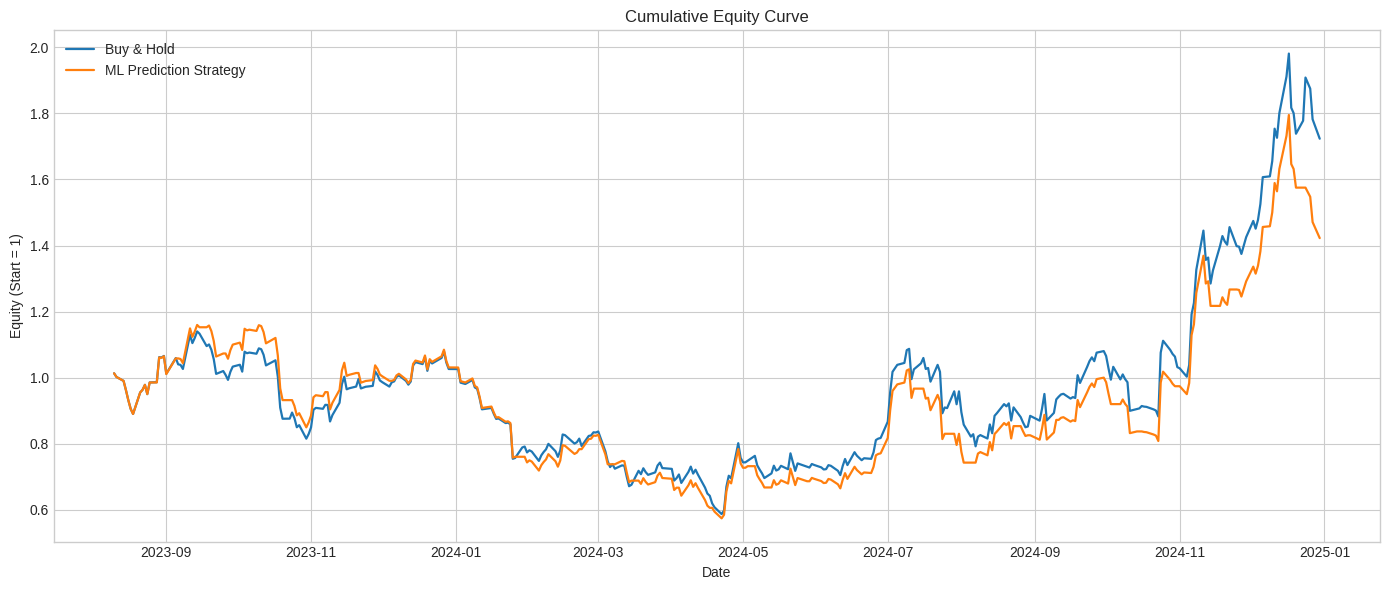

In [16]:
# 16. 누적 수익률 곡선 시각화

plt.figure(figsize=(14, 6))
plt.plot(test.index, test["BuyHold_Equity"], label="Buy & Hold", linewidth=1.6)
plt.plot(test.index, test["Strategy_Equity"], label="ML Prediction Strategy", linewidth=1.6)

plt.title("Cumulative Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity (Start = 1)")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Drawdown 계산과 시각화
최대손실폭(MDD)을 더 직관적으로 보기 위해 drawdown 곡선을 직접 그립니다.


In [17]:
# 17. Drawdown 계산 함수 및 시리즈 생성

def drawdown_series(returns):
    equity_curve = (1 + pd.Series(returns).dropna()).cumprod()
    running_max = equity_curve.cummax()
    dd = equity_curve / running_max - 1
    return dd

test["BuyHold_Drawdown"] = drawdown_series(test["BuyHold_Return"]).values
test["Strategy_Drawdown"] = drawdown_series(test["Strategy_Return"]).values

display(test[["BuyHold_Drawdown", "Strategy_Drawdown"]].head())


,BuyHold_Drawdown,Strategy_Drawdown
Date,,
2023-08-10,0.000000,0.000000
2023-08-11,-0.010964,-0.010964
2023-08-14,-0.022744,-0.022744
2023-08-15,-0.050461,-0.050461
2023-08-16,-0.080460,-0.080460


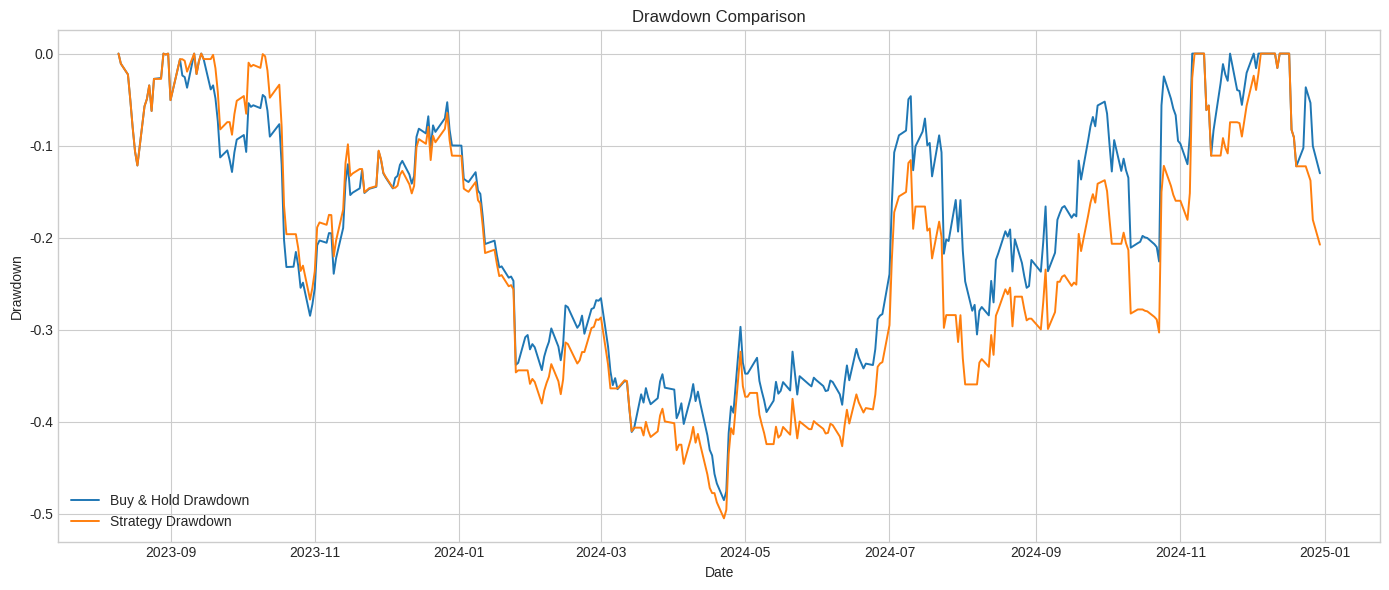

In [18]:
# 18. Drawdown 시각화

plt.figure(figsize=(14, 6))
plt.plot(test.index, test["BuyHold_Drawdown"], label="Buy & Hold Drawdown", linewidth=1.4)
plt.plot(test.index, test["Strategy_Drawdown"], label="Strategy Drawdown", linewidth=1.4)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()


## 13. 해석 팁

### 샤프 지수
- 전체 변동성을 위험으로 본다.
- 상승 변동과 하락 변동을 모두 위험으로 취급한다.

### 소르티노 지수
- 하락 변동성만 위험으로 본다.
- 투자자 입장에서는 더 실질적인 리스크 평가일 수 있다.

### 최대손실폭(MDD)
- 투자자가 실제로 겪을 수 있는 가장 큰 고통에 가까운 지표다.
- 수익률 못지않게 실무적으로 중요하다.


## 14. 최종 정리
이번 실습에서 우리는:

1. TSLA 데이터를 다운로드하고  
2. 일별 수익률을 계산하고  
3. 최근 수익률로 다음날 수익률을 예측한 뒤  
4. 그 예측을 이용해 단순 전략을 만들고  
5. 다음 지표를 계산했습니다.

- Sharpe Ratio
- Sortino Ratio
- Cumulative Return
- Annual Return
- Annual Volatility
- Maximum Drawdown

핵심 메시지는, 좋은 백테스트는 단순히 **수익률이 높은가**만 보는 것이 아니라  
**위험 대비 수익성, 하방 위험, 변동성, 최대 낙폭**을 함께 봐야 한다는 점입니다.


## 15. 연습문제
1. 선형회귀 대신 `RandomForestRegressor`를 사용해 같은 전략을 다시 백테스트해 보세요.  
2. `Position`을 0/1 대신 -1/1로 바꿔 long-short 전략으로 확장해 보세요.  
3. 거래비용을 하루당 0.1% 반영하면 성과지표가 어떻게 달라지는지 비교해 보세요.  
4. TSLA 대신 AAPL, MSFT, NVDA로 바꾸어 성과를 비교해 보세요.  
5. 샤프 지수와 소르티노 지수가 서로 다르게 나오는 이유를 데이터 특성과 연결해 설명해 보세요.
